# **Percentile-Based Outlier Detection & Winsorization**

The **Percentile Method** is a highly flexible, non-parametric approach to outlier detection. Instead of calculating complex statistical metrics like standard deviations or Interquartile ranges, it sets hard operational thresholds based directly on the relative rank of your data points. 

Once these thresholds are established, we apply the **Winsorization Technique** (Capping) to cleanly manage the outliers without dropping any rows from the dataset.

---

## 1. Core Mathematical Concept: The Percentile Method

The percentile method involves sorting your numerical data from smallest to largest and defining fixed, asymmetric percentage boundaries at the absolute edges of the distribution.

### Setting the Thresholds (The Percentile Cut-offs)

Data scientists typically establish standard extreme percentiles to isolate anomalies:
*   **The Upper Threshold:** Fixed at the **99th Percentile** or **97.5th Percentile**. Any data point higher than this value represents the top 1% or 2.5% of extreme entries.

*   **The Lower Threshold:** Fixed at the **1st Percentile** or **2.5th Percentile**. Any data point lower than this value represents the bottom 1% or 2.5% of extreme entries.

Unlike the Z-score or IQR methods—where thresholds can sometimes extend past your actual data limits (like calculating a negative lower fence for age)—the percentile method **guarantees** the boundaries land exactly on real, existing data values.

---

## 2. Handling Outliers: The Winsorization Technique

Once your percentile thresholds are defined, **Winsorization** is the specific algorithmic action taken to resolve the outliers. 

Instead of trimming (deleting) rows, Winsorization replaces extreme values with the nearest calculated percentile threshold boundary. It effectively shrinks the outliers into acceptable maximums and minimums.

### The Conversion Logic
*   If a raw data value is **greater than the 99th percentile**, it is immediately overwritten and changed to match the exact value at the 99th percentile.
*   If a raw data value is **less than the 1st percentile**, it is immediately overwritten and changed to match the exact value at the 1st percentile.
*   All data points falling between the 1st and 99th percentiles are left completely untouched.

*Example:* Consider a dataset where the 99th percentile for `Age` is calculated to be **78**. If a record enters your pipeline with an age of **105**, Winsorization caps that age and rewrites it to **78**.

---

## 3. Prerequisites for Use (When to Apply)

*   **Heavily Skewed, Multi-Modal, or Arbitrary Distributions:** This technique requires absolutely no assumptions about distribution symmetry or bell curves. It works perfectly on anything from exponential decay distributions to highly clustered datasets.

*   **Domain-Driven Fixed Requirements:** Ideal when a business logic rule dictates an explicit cap (e.g., "We only want to evaluate the core 98% of our web traffic and cap the top and bottom 1% of anomalies").

---

## 4. Advantages (Benefits)

*   **100% Data Volume Preservation:** Because it overrides values instead of deleting rows, your dataset dimensions remain completely uncompromised. You preserve all neighboring clean features in that row.

*   **No Out-of-Bounds Glitches:** It will never generate mathematically impossible fence posts (such as a negative lower bound on features like price or weight), which frequently happens when using standard deviations or IQR on skewed boundaries.

---

## 5. Disadvantages and Risks (Why to Avoid)

*   **Artificial Boundary "Spikes":** Because all extreme outliers are compressed into a single value, Winsorization forces an artificial "pile-up" or spike of identical numbers directly at the 1st and 99th percentile thresholds. This artificial frequency spike can distort standard error metrics in linear models.

*   **Forced Outlier Creation:** If a column contains a perfectly clean distribution with absolutely zero genuine anomalies, the percentile method will **still** aggressively target the top and bottom 1% of your data and modify them, inadvertently tampering with perfectly healthy records.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Importing DataSet
df = pd.read_csv("../../data/weight_height.csv")
print(f"Shape of the DataFrame: {df.shape}")
df.sample(5)

Shape of the DataFrame: (10000, 3)


,Gender,Height,Weight
2573,Male,69.895624,200.120361
5364,Female,59.805093,102.147230
8828,Female,64.659179,134.808478
781,Male,70.477591,200.247996
6624,Female,54.616858,71.393749


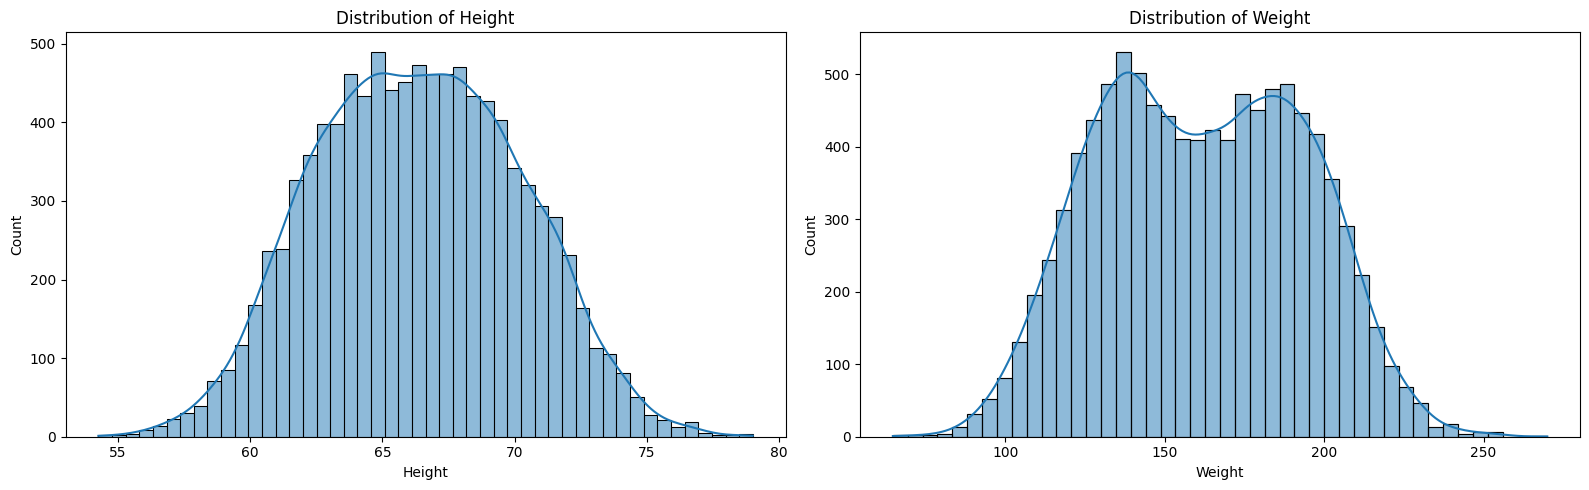

In [4]:
# Distribution plot of the features

def plot_dist(df, feat1, feat2):
    
    fig, axes = plt.subplots(1,2, figsize=(16,5))
    
    # For Feature 1:
    sns.histplot(df[feat1], ax=axes[0], kde=True)
    axes[0].set_title(f'Distribution of {feat1}')
    
    # For Feature 2:
    sns.histplot(df[feat2], kde=True, ax=axes[1])
    axes[1].set_title(f'Distribution of {feat2}')
    
    plt.tight_layout()
    plt.show()

plot_dist(df, 'Height', 'Weight')

In [5]:
# Skewness of the features
print("Height skewness:", np.round(df['Height'].skew(),4))
print("Weight skewness:", np.round(df['Weight'].skew(),4))

Height skewness: 0.0494
Weight skewness: 0.033


## 1. Height

In [6]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

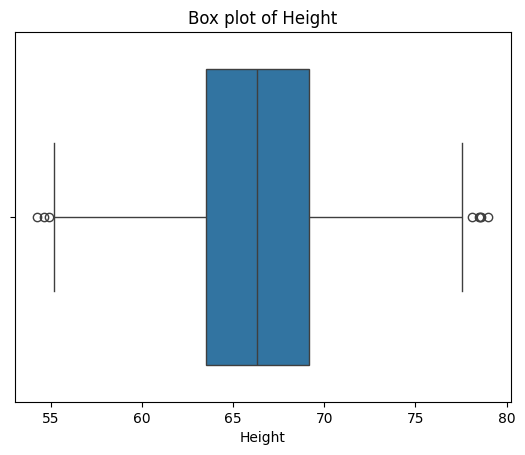

In [7]:
# Box Plot
sns.boxplot(x=df['Height'])
plt.xlabel('Height')
plt.title('Box plot of Height')
plt.show()

# By looking at the box plot, we can see that there are outliers in the data.
# The height of some individuals is very high compared to others. 
# This could be due to various reasons such as obesity, muscle mass, or other factors. Therefore, it's important to handle these outliers before further analysis.


In [8]:
# Custom Boundary Limits
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)

print("Upper limit:", upper_limit)
print("Lower limit:", lower_limit)

Upper limit: 74.7857900583366
Lower limit: 58.13441158671655


In [9]:
## Finding Outliers:
upper_outlier = df[df['Height'] > upper_limit]
lower_outlier = df[df['Height'] < lower_limit]

# Merge upper and lower outliers
outliers = pd.concat([upper_outlier, lower_outlier])
outliers

print(f"Number of Upper Outliers: {len(upper_outlier)}")
print(f"Number of Lower Outliers: {len(lower_outlier)}")

Number of Upper Outliers: 100
Number of Lower Outliers: 100


### 1. Trimming

In [10]:
# Removing Outliers:
new_df = df.drop(outliers.index)
new_df['Height'].describe()


count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64

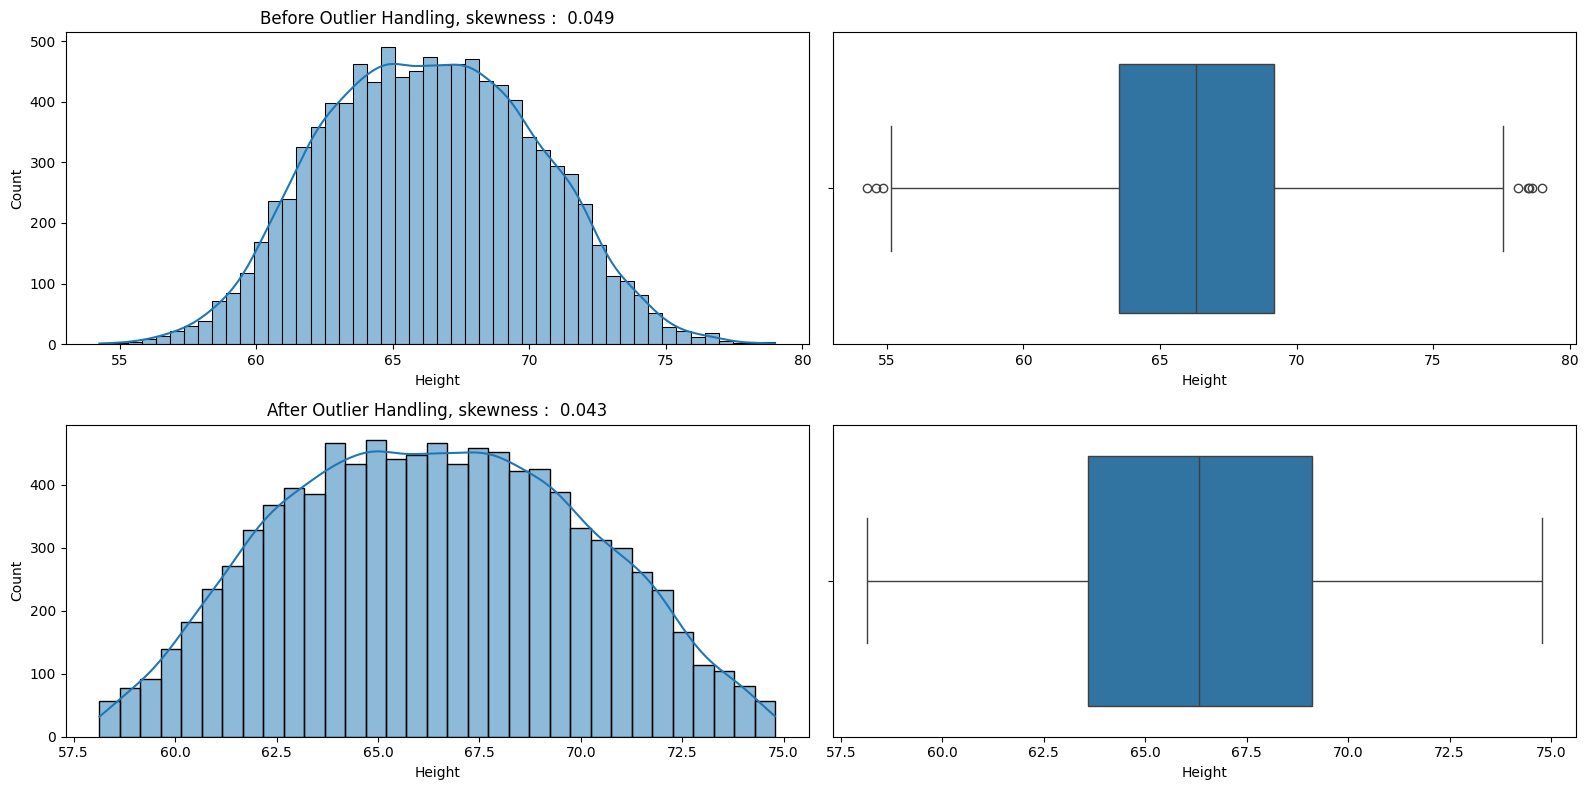

In [11]:
# Box Plot Before and After Outlier Handling
def box_plot(df, new_df, feature):
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))

    # Before Outlier Handling
    sns.histplot(df[feature], kde=True, ax=axes[0, 0])
    sns.boxplot(x=df[feature], ax=axes[0, 1])
    axes[0,0].set_title(f'Before Outlier Handling, skewness :  {df[feature].skew():.3f}')

    # After Outlier Handling
    sns.histplot(new_df[feature], kde=True, ax=axes[1, 0])
    sns.boxplot(x=new_df[feature], ax=axes[1, 1])
    axes[1,0].set_title(f'After Outlier Handling, skewness :  {new_df[feature].skew():.3f}')

    plt.tight_layout()
    plt.show()



box_plot(df, new_df, 'Height') # Before and After Outlier Handling


### 2. Capping (Winsorization)

In [12]:
new_df_cap = df.copy()
new_df_cap['Height'] = np.clip(df['Height'], lower_limit, upper_limit)
new_df_cap['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

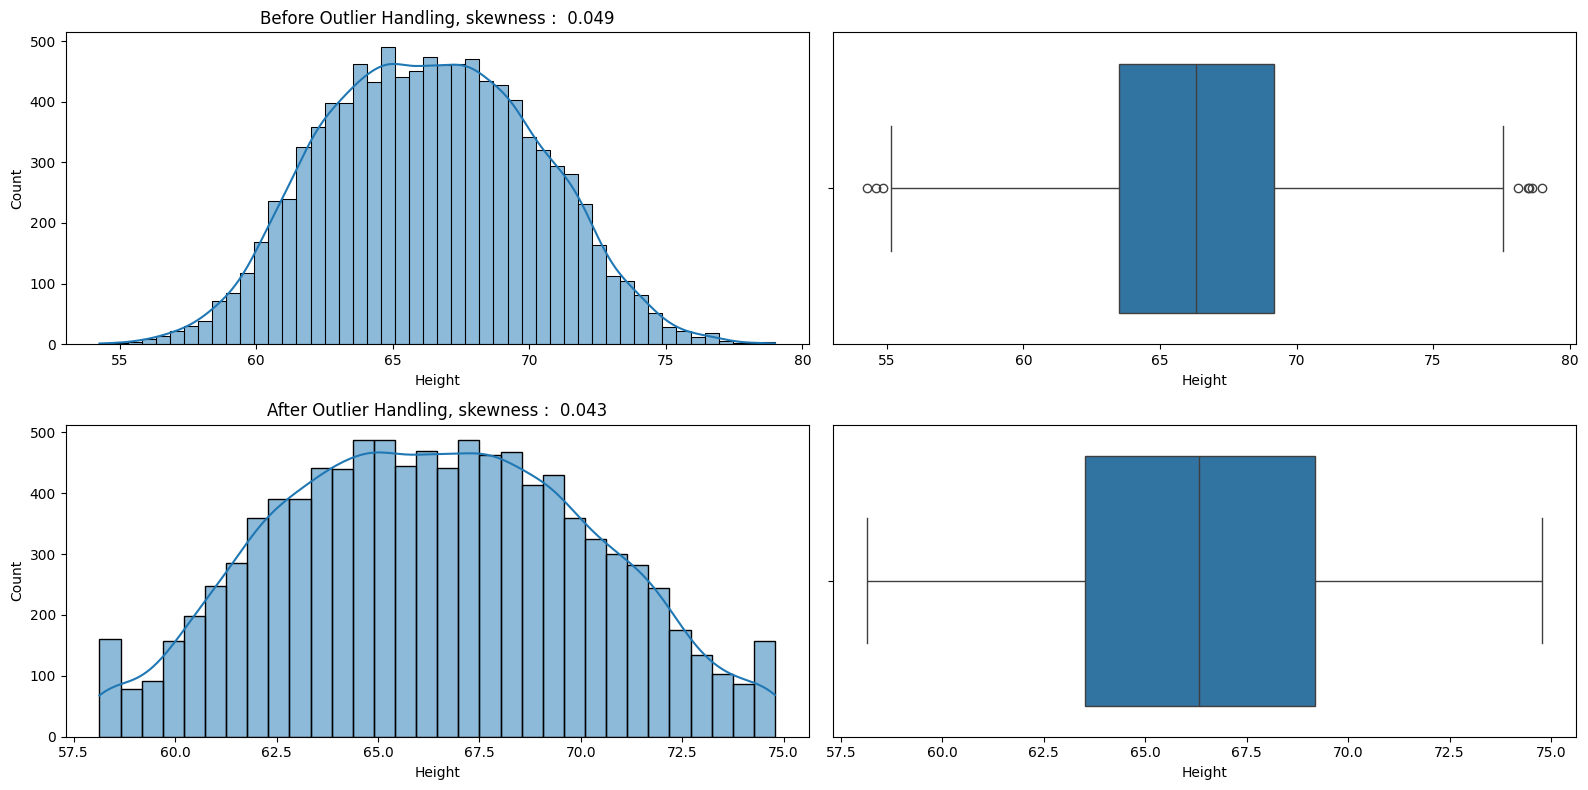

In [13]:
box_plot(df, new_df_cap, 'Height') # Before and After Outlier Handling

## 2. Weight

In [14]:
df['Weight'].describe()

count    10000.000000
mean       161.440357
std         32.108439
min         64.700127
25%        135.818051
50%        161.212928
75%        187.169525
max        269.989699
Name: Weight, dtype: float64

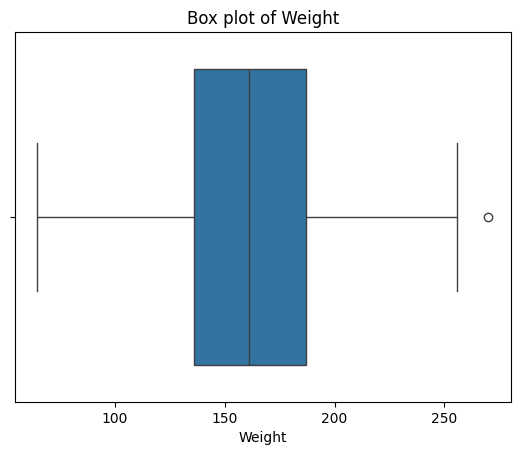

In [15]:
# Box Plot
sns.boxplot(x=df['Weight'])
plt.xlabel('Weight')
plt.title('Box plot of Weight')
plt.show()

# From the box plot there is only one outlier in upper bound as data is right skewed.
# So, we can use Winsorization to remove this outlier.


In [16]:
# Custom Boundary Limits for Weight
upper_limit_w = df['Weight'].quantile(0.9999)
lower_limit_w = df['Weight'].quantile(0.0001)

print("Upper limit:", upper_limit_w)
print("Lower limit:", lower_limit_w)

Upper limit: 255.86473913009024
Lower limit: 68.98210185090404


In [17]:
## Finding Outliers:
upper_outlier_w = df[df['Weight'] > upper_limit_w]
lower_outlier_w = df[df['Weight'] < lower_limit_w]

# Merge upper and lower outliers
outliers = pd.concat([upper_outlier, lower_outlier])
outliers

print(f"Number of Upper Outliers: {len(upper_outlier_w)}")
print(f"Number of Lower Outliers: {len(lower_outlier_w)}")

Number of Upper Outliers: 1
Number of Lower Outliers: 1


### Capping 

In [18]:
new_df_cap = df.copy()
new_df_cap['Weight'] = np.clip(df['Weight'], lower_limit_w, upper_limit_w)
new_df_cap['Weight'].describe()

count    10000.000000
mean       161.439373
std         32.102712
min         68.982102
25%        135.818051
50%        161.212928
75%        187.169525
max        255.864739
Name: Weight, dtype: float64

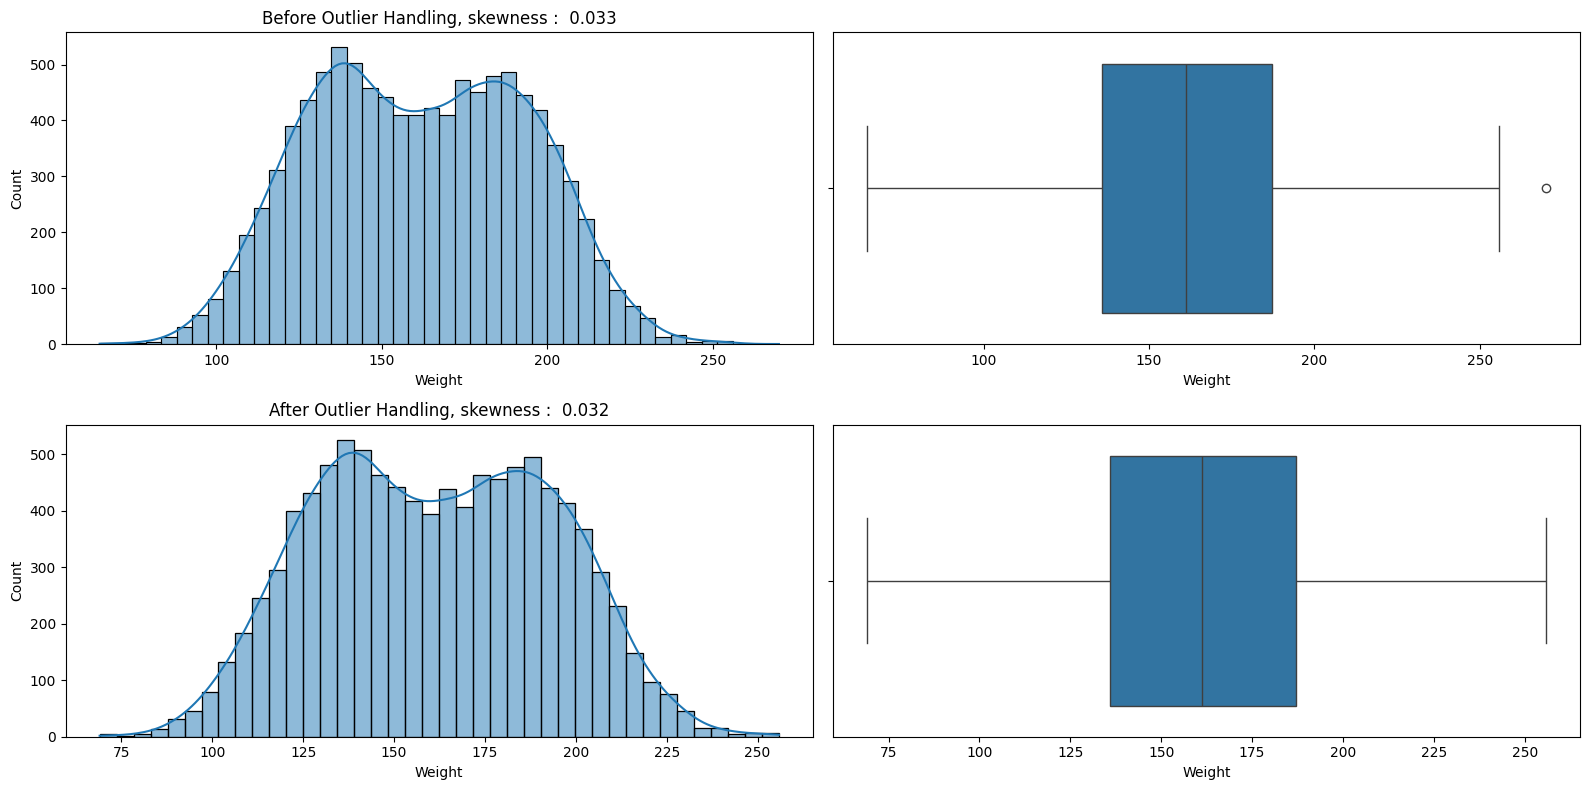

In [19]:
box_plot(df, new_df_cap, 'Weight') # Before and After Outlier Handling